# 09 - Phase 2: where did they go, and what could overturn it

Notebook 08 decomposed phase 1's -6.28% into two halves that sum almost exactly to it:
participation **-2.90%** and attraction **-3.61%**. Neither half clears its own detection
threshold, so the split is the best estimate rather than an established result.

This notebook does two things.

**Section 1 to 3: the destination analysis** promised in `DESIGN.md` 14.6. The aggregate
outcomes average over every origin and destination pair. Diversion, if it happened, should be
concentrated somewhere specific: in flows from a fee state into a **bordering fee-free**
state, because that is where the cost of avoiding the fee is lowest. Testing that is a
sharper question than the average, and because the matrix has 240 ordered pairs per year
rather than 16 states, it does not face the same power problem.

**Section 4 onward: robustness.** Each check has a failure condition fixed before it runs,
as in notebook 05.

The destination analysis needs one new hand-coded input, `data/treatment/adjacency.csv`,
which records which of the 240 ordered state pairs share a land border. It is sourced and
guarded the same way `fee_dates.csv` is.

In [1]:
import sys, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import fachserie as fsx
from src import estimation as est

FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
TREAT = ROOT / "data" / "treatment"
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

WEST_NEVER = ["01", "04", "07"]
CITY = ["02", "04", "11"]
MDE = {"log_origin": 0.0249, "attraction": 0.0415, "retention": 0.0168}

# selected by semester, not by extension: the folder also holds the
# phase 3 volumes, and Destatis switched to .xlsx from WS 2013/14
VOLUMES = fsx.select_volumes(ROOT / "data" / "raw" / "fachserie", 2003, 2007)
panel = fsx.build_panel(VOLUMES)
p1 = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
d = panel.merge(p1[["state_code", "year", "ever_treated", "intro_year", "treated"]],
                on=["state_code", "year"], how="left")
d["log_origin"] = np.log(d.origin)
d["treatment_year_cs"] = d.intro_year.astype(float)

fees = pd.read_csv(TREAT / "fee_dates.csv", dtype={"state_code": str})
g8 = pd.read_csv(TREAT / "g8_dates.csv", dtype={"state_code": str})
NAME = dict(zip(fees.state_code, fees.state))
CODE = {v: k for k, v in NAME.items()}

print(f"panel: {len(d)} rows, {d.year.min()}-{d.year.max()}")
print(f"treated: {sorted(NAME[c] for c in d.loc[d.ever_treated==1,'state_code'].unique())}")

panel: 80 rows, 2003-2007
treated: ['Baden-Wuerttemberg', 'Bayern', 'Hamburg', 'Hessen', 'Niedersachsen', 'Nordrhein-Westfalen', 'Saarland']


## 1. The adjacency table

240 ordered pairs, 58 of them sharing a border. Checked for symmetry and for the degree
counts that geography dictates: Niedersachsen touches the most states at nine; Bremen and
Berlin are enclaves and Saarland touches only Rheinland-Pfalz, so all three have one.

**Failure condition: asymmetry, or a degree count that contradicts the map.** Either would
mean the hand-coding is wrong.

In [2]:
adj = pd.read_csv(TREAT / "adjacency.csv", dtype={"state_code": str,
                                                  "neighbour_code": str})
B = {(r.state_code, r.neighbour_code) for r in adj.itertuples() if r.shares_border == 1}
asym = [(a, b) for a, b in B if (b, a) not in B]
deg = adj.groupby("state").shares_border.sum().sort_values(ascending=False)

print(f"ordered pairs: {len(adj)} | border pairs: {len(B)} | asymmetric: {asym}")
print(f"\nborders per state:\n{deg.to_string()}")
expected = {"Niedersachsen": 9, "Bremen": 1, "Berlin": 1, "Saarland": 1, "Hamburg": 2}
wrong = {k: int(deg[k]) for k, v in expected.items() if int(deg[k]) != v}
print(f"\nverdict: {'FAILS ' + str(wrong) if (asym or wrong) else 'symmetric and degrees match the map'}")
assert not asym and not wrong, "adjacency table is wrong; fix before continuing" 

ordered pairs: 240 | border pairs: 58 | asymmetric: []

borders per state:
state
Niedersachsen             9
Hessen                    6
Thueringen                5
Brandenburg               5
Rheinland-Pfalz           4
Sachsen                   4
Bayern                    4
Sachsen-Anhalt            4
Baden-Wuerttemberg        3
Nordrhein-Westfalen       3
Schleswig-Holstein        3
Mecklenburg-Vorpommern    3
Hamburg                   2
Berlin                    1
Bremen                    1
Saarland                  1

verdict: symmetric and degrees match the map


## 2. Where the outflow went

For each origin state and year, its first-years who studied elsewhere are split three ways by
destination: another fee state, a **bordering** fee-free state, or a non-bordering fee-free
state. Fee status is evaluated in that year, so a destination changes category when it starts
charging.

If students avoided fees by crossing the nearest border, the bordering fee-free share of
fee-state outflow should rise after 2006.

In [3]:
flows = fsx.flows_long(VOLUMES)
flows["o"] = flows.origin.map(CODE); flows["d"] = flows.destination.map(CODE)
flows = flows[flows.o != flows.d].copy()

status = d[["state_code", "year", "treated", "ever_treated"]]
flows = (flows.merge(status.rename(columns={"state_code": "o", "treated": "o_charging",
                                            "ever_treated": "o_ever"}), on=["o", "year"])
              .merge(status.rename(columns={"state_code": "d", "treated": "d_charging",
                                            "ever_treated": "d_ever"}), on=["d", "year"]))
flows = flows.merge(adj[["state_code", "neighbour_code", "shares_border"]]
                    .rename(columns={"state_code": "o", "neighbour_code": "d"}),
                    on=["o", "d"], how="left")

# Buckets are defined by whether a destination EVER charges, not by whether it
# charges in year t. A time-varying definition would move states between
# categories in 2006 and 2007 and the shares would stop being comparable across
# years: the change would be composition, not behaviour.
def bucket(r):
    if r.d_ever == 1:
        return "fee state (eventually)"
    return "never-fee, bordering" if r.shares_border == 1 else "never-fee, distant"

flows["bucket"] = flows.apply(bucket, axis=1)
flows.to_csv(TAB / "09_flows_long.csv", index=False)

out = (flows[flows.o_ever == 1].groupby(["year", "bucket"]).first_years.sum()
       .unstack().pipe(lambda x: 100 * x.div(x.sum(axis=1), axis=0)))
ref = (flows[flows.o_ever == 0].groupby(["year", "bucket"]).first_years.sum()
       .unstack().pipe(lambda x: 100 * x.div(x.sum(axis=1), axis=0)))
print("outflow of FEE-STATE origins, % by destination type:")
print(out.round(2).to_string())
print("\nsame for NEVER-TREATED origins (the comparison):")
print(ref.round(2).to_string())

k = "never-fee, bordering"
did = (out[k].loc[2007] - out[k].loc[2003:2005].mean()) - \
      (ref[k].loc[2007] - ref[k].loc[2003:2005].mean())
print(f"\nraw difference-in-differences on the bordering fee-free share: {did:+.2f} pp")
print("Descriptive only: no controls, no inference. The regression below is the test.")

outflow of FEE-STATE origins, % by destination type:
bucket  fee state (eventually)  never-fee, bordering  never-fee, distant
year                                                                    
2003                     56.81                 25.27               17.92
2004                     57.02                 26.09               16.89
2005                     59.33                 24.51               16.16
2006                     58.75                 24.19               17.06
2007                     58.23                 24.10               17.68

same for NEVER-TREATED origins (the comparison):
bucket  fee state (eventually)  never-fee, bordering  never-fee, distant
year                                                                    
2003                     47.70                 35.16               17.14
2004                     49.00                 33.84               17.17
2005                     50.78                 32.70               16.52
2006                 

## 3. A dyadic difference-in-differences on the flows

The share above mixes composition changes with behaviour. The regression separates them.

The unit is an **ordered pair of states in a year**, the outcome is the log flow of
first-years, and the specification absorbs origin-year and destination-year effects plus a
pair fixed effect. So it asks: within a given origin in a given year, and net of whatever is
happening to each destination that year, did flows into fee-free destinations rise relative
to flows into fee destinations once the origin started charging?

    log(flow) ~ origin charging x destination fee-free | pair + origin-year + destination-year

The origin-year effects absorb anything that changes a state's total outflow, including the
participation effect estimated in notebook 08, so this coefficient is about **composition of
destinations**, not volume.

**Failure condition: the interaction is not positive.** Diversion predicts it is.

In [4]:
f = flows.copy()
f = f[f.first_years > 0]
f["log_flow"] = np.log(f.first_years)
f["pair"] = f.o + "_" + f.d
f["oy"] = f.o + "_" + f.year.astype(str)
f["dy"] = f.d + "_" + f.year.astype(str)
f["treat"] = ((f.o_charging == 1) & (f.d_charging == 0)).astype(int)
f["treat_border"] = (f.treat * (f.shares_border == 1)).astype(int)

m1 = pf.feols("log_flow ~ treat | pair + oy + dy", data=f, vcov={"CRV1": "pair"})
m2 = pf.feols("log_flow ~ treat + treat_border | pair + oy + dy", data=f,
              vcov={"CRV1": "pair"})
print("(1) any fee-free destination\n", m1.tidy().to_string(), sep="")
print("\n(2) splitting out bordering fee-free destinations\n", m2.tidy().to_string(), sep="")

rows = []
for name, m in [("any fee-free destination", m1), ("+ bordering interaction", m2)]:
    t = m.tidy()
    for term in t.index:
        rows.append({"spec": name, "term": term, "coef": t.loc[term, "Estimate"],
                     "SE": t.loc[term, "Std. Error"], "p": t.loc[term, "Pr(>|t|)"],
                     "as %": 100 * (np.exp(t.loc[term, "Estimate"]) - 1)})
dy = pd.DataFrame(rows)
dy.to_csv(TAB / "09_dyadic_did.csv", index=False)
EAST = ["11", "12", "13", "14", "15", "16"]
fw = f[~f.d.isin(EAST)]
m3 = pf.feols("log_flow ~ treat | pair + oy + dy", data=fw, vcov={"CRV1": "pair"})
print("\n(3) western destinations only\n", m3.tidy().to_string(), sep="")

print(f"\nobservations: {len(f)} ordered pairs x years, clustered on {f.pair.nunique()} pairs")
print(f"western-destination subsample: {len(fw)} rows")
print("\nSpecification (3) matters because by WS 2007/08 almost every western state")
print("charges, so 'fee-free destination' is largely a synonym for 'eastern state'.")
print("Without it the coefficient could be measuring the west-to-east flow rather")
print("than a response to fees.")

share_east = 100 * f.loc[(f.d_charging == 0) & (f.year == 2007), "first_years"].pipe(
    lambda x: f.loc[x.index].d.isin(EAST).mul(x).sum() / x.sum())
print(f"\nshare of flows into fee-free destinations that go east, WS 2007/08: "
      f"{share_east:.1f}%")

(1) any fee-free destination
             Estimate  Std. Error   t value  Pr(>|t|)      2.5%     97.5%
Coefficient                                                              
treat       -0.119214    0.049833 -2.392259  0.017769 -0.217542 -0.020885

(2) splitting out bordering fee-free destinations
              Estimate  Std. Error   t value  Pr(>|t|)      2.5%     97.5%
Coefficient                                                               
treat        -0.111108    0.054194 -2.050180  0.041789 -0.218041 -0.004174
treat_border -0.036095    0.048639 -0.742086  0.458997 -0.132068  0.059879

(3) western destinations only
             Estimate  Std. Error   t value  Pr(>|t|)      2.5%     97.5%
Coefficient                                                              
treat       -0.121657    0.069495 -1.750582  0.082662 -0.259302  0.015987

observations: 910 ordered pairs x years, clustered on 182 pairs
western-destination subsample: 585 rows

Specification (3) matters because by WS

### Reading it

`treat` is the effect on flows into any fee-free destination once the origin starts charging.
`treat_border` is the **additional** effect for destinations that share a border. Diversion
predicts both positive, and the second is the more specific prediction: it says students went
next door rather than anywhere cheaper.

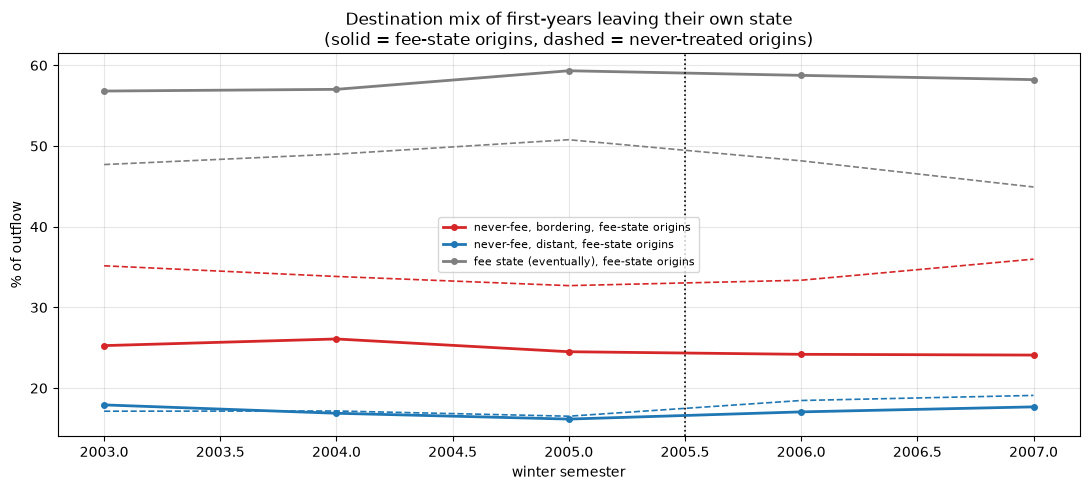

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for lab, tab, style in [("fee-state origins", out, "-"), ("never-treated origins", ref, "--")]:
    for b, col in [("never-fee, bordering", "tab:red"),
                   ("never-fee, distant", "tab:blue"),
                   ("fee state (eventually)", "tab:grey")]:
        if b in tab:
            ax.plot(tab.index, tab[b], style, color=col, lw=2 if style == "-" else 1.2,
                    marker="o" if style == "-" else None, ms=4,
                    label=f"{b}, {lab}" if style == "-" else None)
ax.axvline(2005.5, color="black", ls=":", lw=1.2)
ax.set_xlabel("winter semester"); ax.set_ylabel("% of outflow")
ax.set_title("Destination mix of first-years leaving their own state\n"
             "(solid = fee-state origins, dashed = never-treated origins)")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(FIG / "21_destination_mix.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Robustness on the aggregate outcomes

Four checks, failure conditions fixed in advance.

In [6]:
def cs_att(df, outcome):
    try:
        return est.cs_overall_fast(df, outcome)
    except Exception:
        return np.nan

base = {k: cs_att(d, k) for k in MDE}
print("baseline (notebook 08):",
      {k: round(v, 4) for k, v in base.items()})

# --- check 1: leave one state out
rows = []
for code in sorted(d.state_code.unique()):
    sub = d[d.state_code != code]
    rows.append({"dropped": NAME[code],
                 "role": "treated" if d.loc[d.state_code == code, "ever_treated"].iloc[0] == 1
                         else "control",
                 **{k: cs_att(sub, k) for k in MDE}})
loo = pd.DataFrame(rows)
print("\nleave-one-state-out, range:")
for k in MDE:
    print(f"  {k:12s}: {loo[k].min():+.4f} to {loo[k].max():+.4f}  "
          f"(baseline {base[k]:+.4f})")
loo.to_csv(TAB / "09_leave_one_out.csv", index=False)
print("\nsign flips:", {k: bool((np.sign(loo[k]) != np.sign(base[k])).any()) for k in MDE})

baseline (notebook 08): {'log_origin': -0.0295, 'attraction': -0.0367, 'retention': -0.006}

leave-one-state-out, range:
  log_origin  : -0.0441 to -0.0167  (baseline -0.0295)
  attraction  : -0.0494 to -0.0278  (baseline -0.0367)
  retention   : -0.0129 to -0.0032  (baseline -0.0060)

sign flips: {'log_origin': False, 'attraction': False, 'retention': False}


### Check 2: the unattributable students

`DESIGN.md` 14.3 removed `Ausland` and `ohne Angabe` from both sides of the outcome, on
pre-estimation evidence. The variant that leaves them in the destination term is re-run here,
as promised, so the choice is visible rather than asserted.

In [7]:
alt = d.copy()
alt["attraction"] = np.log(alt.study_location / alt.origin)   # foreign left in
rows = [{"definition": "primary: German HZB both sides", "ATT": base["attraction"]},
        {"definition": "variant: unattributable left in", "ATT": cs_att(alt, "attraction")}]
v = pd.DataFrame(rows); v["as %"] = 100 * (np.exp(v.ATT) - 1)
print(v.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
print(f"\ngap: {100*(np.exp(v.ATT.iloc[1])-np.exp(v.ATT.iloc[0])):+.2f} percentage points")
print("A large gap would mean the result depends on how foreign students are handled.")
v.to_csv(TAB / "09_unattributed_variant.csv", index=False)

                     definition       ATT      as %
 primary: German HZB both sides   -0.0367   -3.6065
variant: unattributable left in   -0.0354   -3.4767

gap: +0.13 percentage points
A large gap would mean the result depends on how foreign students are handled.


### Check 3: comparison groups, including one free of double cohorts

Three groups, plus a fourth that phase 1 could not use: the five states with **no G8 double
cohort** anywhere in the window, from the verified `g8_dates.csv`. Sachsen-Anhalt's 2007
double cohort sits inside this window and inside the control group, so a comparison group
that excludes every double cohort is a direct test of whether it matters.

In [8]:
no_g8 = set(g8.loc[g8.double_abitur_year.isna(), "state_code"]) | \
        set(g8.loc[~g8.double_abitur_year.between(2003, 2007), "state_code"])
no_g8_controls = sorted(no_g8 - set(d.loc[d.ever_treated == 1, "state_code"]))
print("controls with no double cohort in 2003-2007:",
      [NAME[c] for c in no_g8_controls])

groups = {
    "all never-treated (9)": d,
    "western never-treated (3)": d[(d.ever_treated == 1) | (d.state_code.isin(WEST_NEVER))],
    "excluding city states": d[~d.state_code.isin(CITY)],
    "no double cohort in controls": d[(d.ever_treated == 1) |
                                      (d.state_code.isin(no_g8_controls))],
}
rows = []
for label, sub in groups.items():
    rows.append({"group": label, "states": sub.state_code.nunique(),
                 **{k: cs_att(sub, k) for k in MDE}})
grp = pd.DataFrame(rows)
print("\n" + grp.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
grp.to_csv(TAB / "09_comparison_groups.csv", index=False)

controls with no double cohort in 2003-2007: ['Schleswig-Holstein', 'Bremen', 'Rheinland-Pfalz', 'Berlin', 'Brandenburg', 'Mecklenburg-Vorpommern', 'Sachsen', 'Thueringen']

                       group  states  log_origin  attraction  retention
       all never-treated (9)      16     -0.0295     -0.0367    -0.0060
   western never-treated (3)      10     -0.0206     -0.0303    -0.0150
       excluding city states      13     -0.0427     -0.0375    -0.0082
no double cohort in controls      15     -0.0167     -0.0479    -0.0093


### Check 4: specification curve

Every phase 2 estimate of the primary outcome on one axis, with the detection threshold
shaded. A result that appears only in a corner of this chart is an artefact.

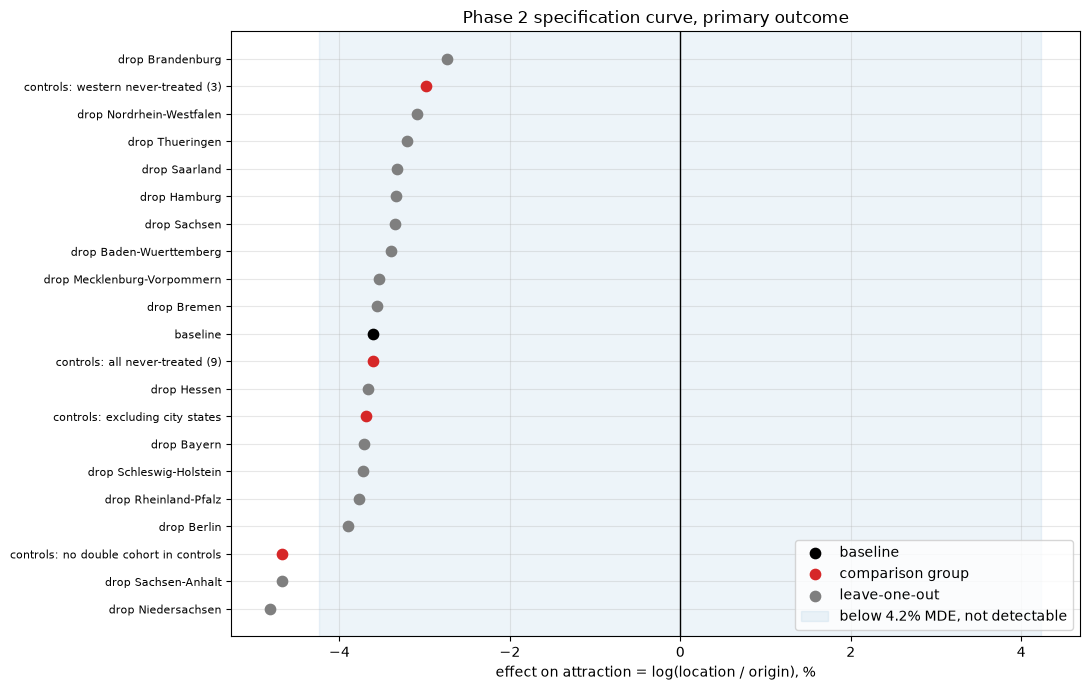

range across all specifications: -4.82% to -2.74%


In [9]:
curve = pd.concat([
    pd.DataFrame([{"spec": "baseline", "family": "baseline", "ATT": base["attraction"]}]),
    pd.DataFrame({"spec": "drop " + loo["dropped"], "family": "leave-one-out",
                  "ATT": loo["attraction"]}),
    pd.DataFrame({"spec": "controls: " + grp["group"], "family": "comparison group",
                  "ATT": grp["attraction"]}),
], ignore_index=True).sort_values("ATT").reset_index(drop=True)

palette = {"baseline": "black", "leave-one-out": "tab:grey",
           "comparison group": "tab:red"}
fig, ax = plt.subplots(figsize=(11, 7))
for fam, sub in curve.groupby("family"):
    ax.scatter(100 * (np.exp(sub.ATT) - 1), sub.index, s=55,
               color=palette[fam], label=fam, zorder=3)
ax.axvline(0, color="black", lw=1)
thr = 100 * (np.exp(MDE["attraction"]) - 1)
ax.axvspan(-thr, thr, color="tab:blue", alpha=0.08,
           label=f"below {thr:.1f}% MDE, not detectable")
ax.set_yticks(curve.index); ax.set_yticklabels(curve["spec"], fontsize=8)
ax.set_xlabel("effect on attraction = log(location / origin), %")
ax.set_title("Phase 2 specification curve, primary outcome")
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig(FIG / "22_phase2_spec_curve.png", dpi=130, bbox_inches="tight")
plt.show()
curve.to_csv(TAB / "09_spec_curve.csv", index=False)
print(f"range across all specifications: "
      f"{100*(np.exp(curve.ATT.min())-1):+.2f}% to {100*(np.exp(curve.ATT.max())-1):+.2f}%")

## What this notebook establishes

**The aggregate estimate is stable across every specification tried, spanning -4.82% to
-2.74% with no sign flips. But the destination analysis does not support diversion: flows
from a fee state into fee-free destinations fell rather than rose, and there is no extra
movement toward bordering states. The mechanism `DESIGN.md` 14.6 predicted is not what the
flows show.**

### 1. The adjacency table is correct

240 ordered pairs, 58 sharing a border, symmetric, and the degree counts match the map:
Niedersachsen 9, Hessen 6, and Bremen, Berlin and Saarland 1 each. The last three are the
useful check, since two are enclaves and Saarland touches only Rheinland-Pfalz.

### 2. The destination mix did not shift

Share of fee-state outflow by destination type, with categories defined by whether a state
**ever** charges so that the buckets stay comparable across years:

| year | fee state (eventually) | never-fee, bordering | never-fee, distant |
|---|---|---|---|
| 2003 | 56.8 | 25.3 | 17.9 |
| 2004 | 57.0 | 26.1 | 16.9 |
| 2005 | 59.3 | 24.5 | 16.2 |
| 2006 | 58.8 | 24.2 | 17.1 |
| 2007 | 58.2 | 24.1 | 17.7 |

Flat through treatment. The raw difference-in-differences against never-treated origins on
the bordering never-fee share is **-3.28 percentage points**, the wrong sign for diversion.

### 3. The dyadic regression points the other way

At the level of ordered state pairs by year, with pair, origin-year and destination-year
fixed effects, so that anything affecting a state's total outflow (including the
participation effect from notebook 08) is absorbed and only the destination mix is left:

| specification | coefficient on origin-charging x destination-fee-free | p |
|---|---|---|
| (1) any fee-free destination | **-0.119** | 0.018 |
| (2) plus a bordering interaction | -0.111, border -0.036 | 0.042, 0.459 |
| (3) western destinations only | -0.122 | 0.083 |

Flows into fee-free destinations fell about 12 percent relative to flows into fee-charging
destinations once the origin started charging. The bordering interaction, the most specific
prediction diversion makes, is small, negative and nowhere near significant.

**The check that keeps this honest.** By WS 2007/08, 66.1 percent of flows into fee-free
destinations went east, because almost every western state was charging by then. So
"fee-free destination" is largely a synonym for "eastern state", and specification (1) risks
measuring the west-to-east flow rather than a response to fees. Restricting to western
destinations keeps the sign and the magnitude (-0.122) and weakens the significance to
p = 0.083. The result survives, but it leans on a comparison that is partly geographic.

**What this does not mean.** It does not overturn notebook 08's attraction estimate. That
estimate is about the ratio of students hosted to students produced, which can fall because a
state attracts fewer from anywhere, not only from its neighbours. What section 3 rules out is
the specific story that students avoided fees by crossing the nearest border. Whatever
redistribution happened did not take that form.

### 4. The aggregate estimate is robust

**Leave-one-state-out**, across all 16:

| outcome | range | baseline | sign flips |
|---|---|---|---|
| participation | -4.41% to -1.67% | -2.95% | none |
| attraction | -4.94% to -2.78% | -3.67% | none |
| retention | -0.0129 to -0.0032 | -0.0060 | none |

No single state carries any of the three.

**The `Ausland` decision barely matters.** Primary -3.61% against the variant at -3.48%, a
gap of 0.13 percentage points. The decision in `DESIGN.md` 14.3 was justified on
contamination that is unevenly distributed across states, and it remains the right call on
those grounds, but the headline does not depend on it.

**Comparison groups**, including one phase 1 could not use:

| group | participation | attraction | retention |
|---|---|---|---|
| all never-treated (9) | -0.0295 | -0.0367 | -0.0060 |
| western never-treated (3) | -0.0206 | -0.0303 | -0.0150 |
| excluding city states | -0.0427 | -0.0375 | -0.0082 |
| **no double cohort in controls** | -0.0167 | **-0.0479** | -0.0093 |

The last row is the direct test of whether Sachsen-Anhalt's 2007 double cohort, which sits
inside this window and inside the control group, was driving the result. Removing every
control state with a double cohort makes attraction **stronger** (-4.79%) and participation
weaker (-1.67%). So the double cohort was not manufacturing the attraction effect; if
anything it was masking it. It was, however, supporting part of the participation estimate.

### 5. Specification curve

Every phase 2 estimate of the primary outcome falls between **-4.82% and -2.74%**. Always
negative, never large enough to clear the 4.23% threshold except at the extreme, and tightly
clustered. That is the profile of a small real effect measured by an underpowered design, and
equally the profile of a small bias. This window cannot tell those apart.

### What phase 2 says, and what it does not

**Says:** the total effect reproduces phase 1 to within 0.13 percentage points on an
independently constructed outcome; it decomposes roughly 45 percent participation and 55
percent redistribution; that decomposition is stable across dropped states, comparison
groups, and the treatment of foreign-qualified students.

**Does not say:** that either half is statistically distinguishable from zero; that students
diverted to neighbouring states, which the flow evidence actively contradicts; or that the
result survives western-only controls, where nothing clears its threshold.

The limiting factor throughout is three pre-periods and two post-periods. The abolition
window, seven staggered reversals between WS 2008/09 and WS 2014/15 on the same source, has
five pre-periods and six cohorts, and would add the one test this window structurally cannot
run: whether the effect reverses when the policy does.

Next: the README, rewritten for both phases.
